# Wall thickness window intensity scan

Uses `scan_folder_h10mmfixed_5meV_2e9` and plots the summed intensity in the two spherical-monitor detector windows. The Born estimate uses volume/projected-area path length, uncertainty propagation follows `thinlimit_4PImon.ipynb`, and curves are separated by sample geometry (`H`, `R`) so different heights/radii are not mixed. The straight-line reduced chi-square is computed from a weighted linear fit to the folded longitude coordinate inside the two detector windows.

In [29]:

from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scan and detector-window settings
psi_dir = Path.cwd()
scan_dir = psi_dir / 'scan_folder_h10mmfixed_5meV_2e9'
plots_dir = psi_dir / 'plots'
plots_dir.mkdir(exist_ok=True)

window_center_deg = 75.0
window_width_deg = 60.0
latitude_halfwidth_deg = 2.0

# Same error propagation mode as thinlimit_4PImon.ipynb.
monitor_error_correlation_mode = 'independent_pixels'

# Monitor correction settings. These match PSI_instrument_plots.ipynb.
spherical_cosine_correction = True
spherical_cosine_floor = 1e-6
spherical_pole_cut_deg = 10.0

# Born estimate settings. Use volume/projected-area because the sample-flux monitor grid is too coarse for thin walls.
psi_sigma_inc_cm_inv = 0.367
psi_sigma_abs_cm_inv = psi_sigma_inc_cm_inv
psi_sigma_coh_cm_inv = 1.786e-3
psi_sigma_total_cm_inv = psi_sigma_inc_cm_inv + psi_sigma_coh_cm_inv + psi_sigma_abs_cm_inv
psi_born_probability_mode = 'volume_over_projected_area'
psi_include_lids_for_born = True
preferred_spherical_monitors = ('sample_spherical_monitor_scattered', 'sample_spherical_monitor')

print(f'Scan directory: {scan_dir}')
print(f'Window centers: +/-{window_center_deg:g} deg, width={window_width_deg:g} deg, |latitude| <= {latitude_halfwidth_deg:g} deg')


Scan directory: /Users/christian/Documents/Study/bachelor_project/geometry_optimization/PSI_instrument/scan_folder_h10mmfixed_5meV_2e9
Window centers: +/-75 deg, width=60 deg, |latitude| <= 2 deg


In [30]:

def _parse_float_tuple(text, n):
    return tuple(float(value) for value in text.split(':', 1)[1].split()[:n])


def parse_mccode_params(sim_file):
    params = {}
    pattern = re.compile(r'^\s*#?\s*Param:\s*([A-Za-z0-9_]+)=(.+?)\s*$')
    with Path(sim_file).open('r') as f:
        for line in f:
            match = pattern.match(line)
            if match:
                try:
                    params[match.group(1)] = float(match.group(2))
                except ValueError:
                    pass
    return params


def parse_mccode_dat(path):
    path = Path(path)
    lines = path.read_text(errors='ignore').splitlines()
    meta = {'path': path}
    monitor_type = None
    nx = ny = None

    for line in lines:
        if line.startswith('# type:'):
            monitor_type = line.split(':', 1)[1].strip()
            dim_match = re.search(r'array_(1d|2d)\(([^)]*)\)', monitor_type)
            if dim_match:
                dims = [int(value.strip()) for value in dim_match.group(2).split(',') if value.strip()]
                nx = dims[0] if dims else None
                ny = dims[1] if len(dims) > 1 else None
        elif line.startswith('# component:'):
            meta['component'] = line.split(':', 1)[1].strip()
        elif line.startswith('# xlimits:'):
            meta['xlimits'] = _parse_float_tuple(line, 2)
        elif line.startswith('# xylimits:'):
            meta['xylimits'] = _parse_float_tuple(line, 4)
        elif line.startswith('# values:'):
            values = [float(value) for value in line.split(':', 1)[1].split()[:3]]
            meta['header_total'] = values[0]
            meta['header_error'] = values[1] if len(values) > 1 else np.nan
            meta['header_counts'] = values[2] if len(values) > 2 else np.nan

    data_start = None
    for index, line in enumerate(lines):
        if line.startswith('# Data') and line.rstrip().endswith('I:'):
            data_start = index + 1
            break
    if data_start is None:
        raise ValueError(f'Could not find intensity section in {path.name}')

    rows = []
    for line in lines[data_start:]:
        stripped = line.strip()
        if stripped and not stripped.startswith('#'):
            rows.append([float(value) for value in stripped.split()])
    data = np.array(rows, dtype=float)

    if monitor_type and monitor_type.startswith('array_1d'):
        intensity = data[:, 1] if data.ndim == 2 and data.shape[1] >= 2 else data.reshape(-1)
        meta.update({'kind': '1d', 'I': intensity, 'total': float(np.nansum(intensity))})
        return meta

    intensity = data[:ny, :] if ny is not None and data.shape[0] >= ny else data
    error = data[ny:2 * ny, :] if ny is not None and data.shape[0] >= 2 * ny else None
    counts = data[2 * ny:3 * ny, :] if ny is not None and data.shape[0] >= 3 * ny else None
    meta.update({'kind': '2d', 'I': intensity, 'I_err': error, 'N': counts, 'total': float(np.nansum(intensity)), 'shape': intensity.shape})
    return meta


def load_records(run_dir):
    return [parse_mccode_dat(path) for path in sorted(Path(run_dir).glob('*.dat'))]


def record_by_name(records, names):
    wanted = set(names)
    for record in records:
        if {record['path'].stem, record.get('component', '')} & wanted:
            return record
    return None


def selected_spherical_record(records):
    for name in preferred_spherical_monitors:
        record = record_by_name(records, (name,))
        if record is not None:
            return record
    raise FileNotFoundError('No spherical sample monitor found')


def record_total(record):
    return float(record.get('header_total', record['total']))


def record_total_error(record):
    if record.get('header_error') is not None:
        return float(record['header_error'])
    if record.get('I_err') is not None:
        return float(np.sqrt(np.nansum(np.asarray(record['I_err'], dtype=float) ** 2)))
    return np.nan


def coordinate_centers(record):
    x_min, x_max, y_min, y_max = record['xylimits']
    y_bins, x_bins = record['I'].shape
    x_edges = np.linspace(x_min, x_max, x_bins + 1)
    y_edges = np.linspace(y_min, y_max, y_bins + 1)
    return 0.5 * (x_edges[:-1] + x_edges[1:]), 0.5 * (y_edges[:-1] + y_edges[1:])


def cosine_correct_spherical(record, image):
    corrected = np.ma.masked_invalid(np.asarray(image, dtype=float))
    if not spherical_cosine_correction:
        return corrected

    _, lat_centers = coordinate_centers(record)
    cos_lat = np.cos(np.deg2rad(lat_centers))
    pole_limit = 90.0 - spherical_pole_cut_deg
    valid = (np.abs(cos_lat) >= spherical_cosine_floor) & (np.abs(lat_centers) <= pole_limit)
    corrected[~valid, :] = np.ma.masked
    corrected[valid, :] = corrected[valid, :] / np.abs(cos_lat[valid, None])
    return corrected


def angular_delta_deg(values, center):
    return (values - center + 180.0) % 360.0 - 180.0


def longitude_window_mask(longitude, center_deg):
    return np.abs(angular_delta_deg(longitude, center_deg)) <= window_width_deg / 2.0


def spherical_equator_profile(record):
    image = cosine_correct_spherical(record, record['I'])
    corrected_error = None
    if record.get('I_err') is not None:
        corrected_error = cosine_correct_spherical(record, record['I_err'])

    longitude, latitude = coordinate_centers(record)
    lat_mask = np.abs(latitude) <= latitude_halfwidth_deg
    profile = np.ma.sum(image[lat_mask, :], axis=0)
    if corrected_error is None:
        profile_error = None
    else:
        profile_error = np.ma.sqrt(np.ma.sum(np.ma.asarray(corrected_error)[lat_mask, :] ** 2, axis=0))
    return longitude, latitude, lat_mask, profile, profile_error


def corrected_band_solid_angle_per_longitude_sr(record, latitude_mask):
    x_min, x_max, y_min, y_max = record['xylimits']
    n_lat, n_lon = record['I'].shape
    dlon = np.deg2rad((x_max - x_min) / n_lon)
    lat_edges = np.linspace(y_min, y_max, n_lat + 1)
    lat_centers = 0.5 * (lat_edges[:-1] + lat_edges[1:])

    omega = 0.0
    for i, use_bin in enumerate(latitude_mask):
        if not use_bin:
            continue
        lat1 = np.deg2rad(lat_edges[i])
        lat2 = np.deg2rad(lat_edges[i + 1])
        bin_omega = dlon * (np.sin(lat2) - np.sin(lat1))
        if spherical_cosine_correction:
            cos_lat = np.cos(np.deg2rad(lat_centers[i]))
            if abs(cos_lat) < spherical_cosine_floor:
                continue
            bin_omega /= cos_lat
        omega += bin_omega
    return float(omega)


In [31]:

def psi_geometry_cm(run_dir):
    params = parse_mccode_params(Path(run_dir) / 'mccode.sim')
    return {
        'outer_radius_cm': params['sampleRadius'] * 100.0,
        'outer_height_cm': params['sampleHeight'] * 100.0,
        'wall_thickness_cm': params['sampleThickness'] * 100.0,
    }


def psi_lid_thickness_cm(geometry):
    return geometry['wall_thickness_cm'] if psi_include_lids_for_born else 0.0


def psi_inner_height_cm(geometry):
    return geometry['outer_height_cm'] - 2.0 * psi_lid_thickness_cm(geometry)


def psi_material_volume_cm3(geometry):
    R = geometry['outer_radius_cm']
    H = geometry['outer_height_cm']
    t = geometry['wall_thickness_cm']
    r = R - t
    H_inner = psi_inner_height_cm(geometry)
    return np.pi * R**2 * H - np.pi * r**2 * H_inner


def psi_projected_area_cm2(geometry):
    return 2.0 * geometry['outer_radius_cm'] * geometry['outer_height_cm']


def psi_mean_path_length_cm(geometry):
    return psi_material_volume_cm3(geometry) / psi_projected_area_cm2(geometry)


def psi_probability_from_path_length_cm(path_length_cm):
    path_length_cm = np.asarray(path_length_cm, dtype=float)
    total_probability = 1.0 - np.exp(-psi_sigma_total_cm_inv * path_length_cm)
    return total_probability * psi_sigma_inc_cm_inv / psi_sigma_total_cm_inv


def psi_beam_path_length_map_cm(record, geometry):
    x_centers, y_centers = coordinate_centers(record)
    x = np.asarray(x_centers, dtype=float)
    y = np.asarray(y_centers, dtype=float)
    R = geometry['outer_radius_cm']
    H = geometry['outer_height_cm']
    t = geometry['wall_thickness_cm']
    r = max(R - t, 0.0)

    outer_chord = np.zeros_like(x, dtype=float)
    outer_mask = np.abs(x) <= R
    outer_chord[outer_mask] = 2.0 * np.sqrt(np.maximum(R**2 - x[outer_mask]**2, 0.0))

    inner_chord = np.zeros_like(x, dtype=float)
    inner_mask = np.abs(x) <= r
    inner_chord[inner_mask] = 2.0 * np.sqrt(np.maximum(r**2 - x[inner_mask]**2, 0.0))

    side_path = outer_chord - inner_chord
    in_outer_height = np.abs(y) <= 0.5 * H

    if psi_include_lids_for_born and t > 0.0:
        in_lid = (np.abs(y) >= 0.5 * H - t) & (np.abs(y) <= 0.5 * H)
        in_side_wall = in_outer_height & ~in_lid
        path = np.outer(in_side_wall.astype(float), side_path)
        path += np.outer(in_lid.astype(float), outer_chord)
    else:
        path = np.outer(in_outer_height.astype(float), side_path)
    return path


def psi_beam_weighted_interaction_probability(records, geometry):
    before = record_by_name(records, ('sample_flux_before', 'before'))
    if before is None:
        raise FileNotFoundError('Beam-weighted estimate needs sample_flux_before')
    intensity = np.asarray(before['I'], dtype=float)
    path = psi_beam_path_length_map_cm(before, geometry)
    weights = np.where((path > 0.0) & np.isfinite(intensity), intensity, 0.0)
    total_weight = np.nansum(weights)
    local_probability = psi_probability_from_path_length_cm(path)
    return float(np.nansum(weights * local_probability) / total_weight), float(np.nansum(weights * path) / total_weight)


def psi_intensity_hitting_sample(records):
    before = record_by_name(records, ('sample_flux_before', 'before'))
    after = record_by_name(records, ('sample_flux_after_unscattered', 'after'))
    if before is not None and after is not None:
        before_total = record_total(before)
        after_total = record_total(after)
        before_error = record_total_error(before)
        after_error = record_total_error(after)
        error = np.sqrt(before_error**2 + after_error**2) if np.isfinite(before_error) and np.isfinite(after_error) else np.nan
        return before_total - after_total, error, f"{before['path'].name} - {after['path'].name}"
    direct = record_by_name(records, ('sample_flux_hitting_sample',))
    if direct is not None:
        return record_total(direct), record_total_error(direct), direct['path'].name
    raise FileNotFoundError('No sample flux monitor found')


In [32]:

def weighted_linear_fit_reduced_chi_square(x, y, yerr):
    valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(yerr) & (yerr > 0.0)
    if np.count_nonzero(valid) <= 2:
        return np.nan, np.nan, np.nan

    x = np.asarray(x, dtype=float)[valid]
    y = np.asarray(y, dtype=float)[valid]
    yerr = np.asarray(yerr, dtype=float)[valid]
    weights = 1.0 / yerr**2
    sqrt_w = np.sqrt(weights)
    design = np.column_stack([np.ones_like(x), x])
    coeff, *_ = np.linalg.lstsq(design * sqrt_w[:, None], y * sqrt_w, rcond=None)
    intercept, slope = coeff
    residual = y - (intercept + slope * x)
    dof = y.size - 2
    reduced_chi_square = float(np.sum((residual / yerr) ** 2) / dof) if dof > 0 else np.nan
    return reduced_chi_square, float(intercept), float(slope)


def summarize_run(run_dir):
    records = load_records(run_dir)
    spherical = selected_spherical_record(records)
    longitude, latitude, lat_mask, profile, profile_error = spherical_equator_profile(spherical)
    geometry = psi_geometry_cm(run_dir)

    hit_intensity, hit_error, hit_method = psi_intensity_hitting_sample(records)
    probability_mean_path_cm = psi_mean_path_length_cm(geometry)
    probability = float(psi_probability_from_path_length_cm(probability_mean_path_cm))
    solid_angle = corrected_band_solid_angle_per_longitude_sr(spherical, lat_mask)
    expected_per_lon_bin = hit_intensity * probability * solid_angle / (4.0 * np.pi)

    profile_values = np.ma.filled(np.ma.asarray(profile, dtype=float), np.nan)
    profile_error_values = None
    if profile_error is not None:
        profile_error_values = np.ma.filled(np.ma.asarray(profile_error, dtype=float), np.nan)

    positive_mask = longitude_window_mask(longitude, window_center_deg)
    negative_mask = longitude_window_mask(longitude, -window_center_deg)
    window_mask = positive_mask | negative_mask
    n_window_bins = int(np.count_nonzero(window_mask))

    local_longitude = np.full_like(longitude, np.nan, dtype=float)
    local_longitude[positive_mask] = angular_delta_deg(longitude[positive_mask], window_center_deg)
    local_longitude[negative_mask] = angular_delta_deg(longitude[negative_mask], -window_center_deg)

    linear_fit_reduced_chi_square = np.nan
    linear_fit_intercept = np.nan
    linear_fit_slope = np.nan
    if profile_error_values is not None:
        linear_fit_reduced_chi_square, linear_fit_intercept, linear_fit_slope = weighted_linear_fit_reduced_chi_square(
            local_longitude[window_mask],
            profile_values[window_mask],
            profile_error_values[window_mask],
        )

    observed_window_sum = float(np.nansum(profile_values[window_mask]))
    expected_window_sum = float(expected_per_lon_bin * n_window_bins)
    expected_window_sum_stat_err = (
        expected_window_sum * hit_error / hit_intensity
        if hit_intensity > 0 and np.isfinite(hit_error)
        else np.nan
    )
    expected_window_sum_beam_profile_sys = 0.0
    expected_window_sum_err = np.sqrt(
        np.nansum([
            expected_window_sum_stat_err**2,
            expected_window_sum_beam_profile_sys**2,
        ])
    )

    observed_window_sum_err = np.nan
    if profile_error_values is not None:
        if monitor_error_correlation_mode in ('correlated_longitude_bins', 'fully_correlated_pixels'):
            observed_window_sum_err = float(np.nansum(np.abs(profile_error_values[window_mask])))
        else:
            observed_window_sum_err = float(np.sqrt(np.nansum(profile_error_values[window_mask] ** 2)))

    observed_over_expected = observed_window_sum / expected_window_sum if expected_window_sum > 0 else np.nan
    observed_over_expected_stat_err = np.nan
    observed_over_expected_beam_profile_sys_err = np.nan
    observed_over_expected_err = np.nan
    if expected_window_sum > 0 and observed_window_sum > 0:
        if np.isfinite(observed_window_sum_err) and np.isfinite(expected_window_sum_stat_err):
            observed_over_expected_stat_err = observed_over_expected * np.sqrt(
                (observed_window_sum_err / observed_window_sum)**2
                +
                (expected_window_sum_stat_err / expected_window_sum)**2
            )
        if np.isfinite(expected_window_sum_beam_profile_sys):
            observed_over_expected_beam_profile_sys_err = (
                observed_over_expected
                * expected_window_sum_beam_profile_sys
                / expected_window_sum
            )
        if np.isfinite(observed_over_expected_stat_err) or np.isfinite(observed_over_expected_beam_profile_sys_err):
            observed_over_expected_err = np.sqrt(
                np.nansum([
                    observed_over_expected_stat_err**2,
                    observed_over_expected_beam_profile_sys_err**2,
                ])
            )

    return {
        'run': Path(run_dir).name,
        'thickness_mm': geometry['wall_thickness_cm'] * 10.0,
        'thickness_cm': geometry['wall_thickness_cm'],
        'radius_mm': geometry['outer_radius_cm'] * 10.0,
        'height_mm': geometry['outer_height_cm'] * 10.0,
        'geometry_label': f"H={geometry['outer_height_cm'] * 10.0:g} mm, R={geometry['outer_radius_cm'] * 10.0:g} mm",
        'hit_intensity': hit_intensity,
        'hit_error': hit_error,
        'hit_method': hit_method,
        'interaction_probability': probability,
        'probability_path_mode': psi_born_probability_mode,
        'probability_mean_path_cm': probability_mean_path_cm,
        'solid_angle_per_longitude_bin_sr': solid_angle,
        'expected_per_longitude_bin': expected_per_lon_bin,
        'n_window_bins': n_window_bins,
        'expected_window_sum': expected_window_sum,
        'expected_window_sum_stat_err': expected_window_sum_stat_err,
        'expected_window_sum_beam_profile_sys': expected_window_sum_beam_profile_sys,
        'expected_window_sum_err': expected_window_sum_err,
        'observed_window_sum': observed_window_sum,
        'window_linear_fit_reduced_chi_square': linear_fit_reduced_chi_square,
        'window_linear_fit_intercept': linear_fit_intercept,
        'window_linear_fit_slope_per_deg': linear_fit_slope,
        'observed_window_sum_err': observed_window_sum_err,
        'observed_over_expected': observed_over_expected,
        'observed_over_expected_stat_err': observed_over_expected_stat_err,
        'observed_over_expected_beam_profile_sys_err': observed_over_expected_beam_profile_sys_err,
        'observed_over_expected_err': observed_over_expected_err,
    }


run_dirs = sorted(
    scan_dir.glob('scan_*'),
    key=lambda p: (
        psi_geometry_cm(p)['outer_height_cm'],
        psi_geometry_cm(p)['outer_radius_cm'],
        psi_geometry_cm(p)['wall_thickness_cm'],
    ),
)
results = (
    pd.DataFrame(summarize_run(run_dir) for run_dir in run_dirs)
    .sort_values(['height_mm', 'radius_mm', 'thickness_mm'])
    .reset_index(drop=True)
)
results


,run,thickness_mm,thickness_cm,radius_mm,height_mm,geometry_label,hit_intensity,hit_error,hit_method,interaction_probability,...,expected_window_sum_err,observed_window_sum,window_linear_fit_reduced_chi_square,window_linear_fit_intercept,window_linear_fit_slope_per_deg,observed_window_sum_err,observed_over_expected,observed_over_expected_stat_err,observed_over_expected_beam_profile_sys_err,observed_over_expected_err
0,scan_h10mm_r8mm_t0.25mm_2e9,0.25,0.025,8.0,10.0,"H=10 mm, R=8 mm",10162900.0,8591.711499,sample_flux_before.dat - sample_flux_after_uns...,0.047589,...,4.915717,3955.981532,1.669312,63.800451,-0.000174,1.982303,0.680345,0.000669,0.0,0.000669
1,scan_h10mm_r8mm_t0.5mm_2e9,0.50,0.050,8.0,10.0,"H=10 mm, R=8 mm",10151800.0,8590.683436,sample_flux_before.dat - sample_flux_after_uns...,0.087641,...,9.051863,6703.982265,5.447078,108.103889,-0.002173,2.891205,0.626729,0.000595,0.0,0.000595
2,scan_h10mm_r8mm_t0.75mm_2e9,0.75,0.075,8.0,10.0,"H=10 mm, R=8 mm",10159400.0,8590.789024,sample_flux_before.dat - sample_flux_after_uns...,0.121489,...,12.548050,8869.413328,12.813479,142.997489,-0.001723,3.586692,0.597701,0.000560,0.0,0.000560
3,scan_h10mm_r8mm_t1.0mm_2e9,1.00,0.100,8.0,10.0,"H=10 mm, R=8 mm",10159400.0,8590.164428,sample_flux_before.dat - sample_flux_after_uns...,0.150199,...,15.512174,10558.713076,18.964715,170.215216,0.004224,4.126259,0.575535,0.000536,0.0,0.000536
4,scan_h10mm_r8mm_t1.25mm_2e9,1.25,0.125,8.0,10.0,"H=10 mm, R=8 mm",10155100.0,8590.863425,sample_flux_before.dat - sample_flux_after_uns...,0.174623,...,18.036116,11898.263573,28.138522,191.781253,0.004804,4.552561,0.558076,0.000518,0.0,0.000518
5,scan_h10mm_r8mm_t1.5mm_2e9,1.50,0.150,8.0,10.0,"H=10 mm, R=8 mm",10154300.0,8591.436963,sample_flux_before.dat - sample_flux_after_uns...,0.195452,...,20.188798,12930.832134,42.464846,208.378550,-0.000831,4.883585,0.541916,0.000502,0.0,0.000502
6,scan_h10mm_r8mm_t1.75mm_2e9,1.75,0.175,8.0,10.0,"H=10 mm, R=8 mm",10154300.0,8590.562302,sample_flux_before.dat - sample_flux_after_uns...,0.213246,...,22.024544,13738.507794,55.522641,221.350797,0.003679,5.146898,0.527721,0.000488,0.0,0.000488
7,scan_h10mm_r8mm_t2.0mm_2e9,2.00,0.200,8.0,10.0,"H=10 mm, R=8 mm",10158100.0,8590.589657,sample_flux_before.dat - sample_flux_after_uns...,0.228463,...,23.596242,14354.781804,75.232176,231.218120,0.006973,5.351316,0.514475,0.000475,0.0,0.000475
8,scan_h10mm_r8mm_t2.25mm_2e9,2.25,0.225,8.0,10.0,"H=10 mm, R=8 mm",10156500.0,8590.328282,sample_flux_before.dat - sample_flux_after_uns...,0.241478,...,24.939770,14820.358096,93.479282,238.654863,-0.001641,5.512555,0.502611,0.000464,0.0,0.000464
9,scan_h10mm_r8mm_t2.5mm_2e9,2.50,0.250,8.0,10.0,"H=10 mm, R=8 mm",10161900.0,8590.756624,sample_flux_before.dat - sample_flux_after_uns...,0.252603,...,26.090069,15168.451264,119.978354,244.170623,0.001141,5.638404,0.491499,0.000454,0.0,0.000454


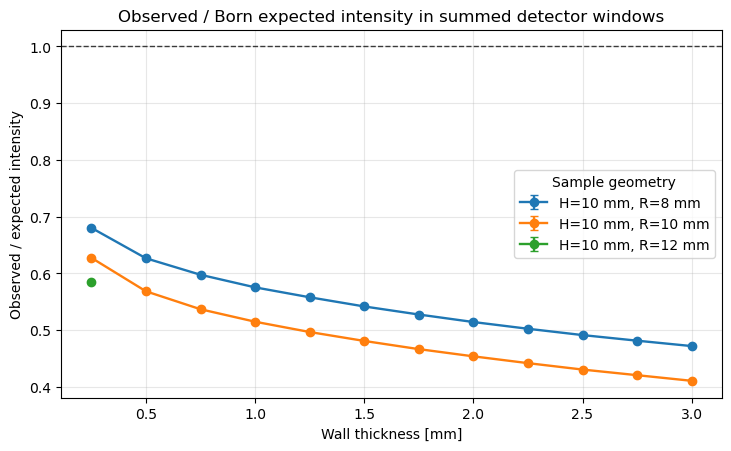

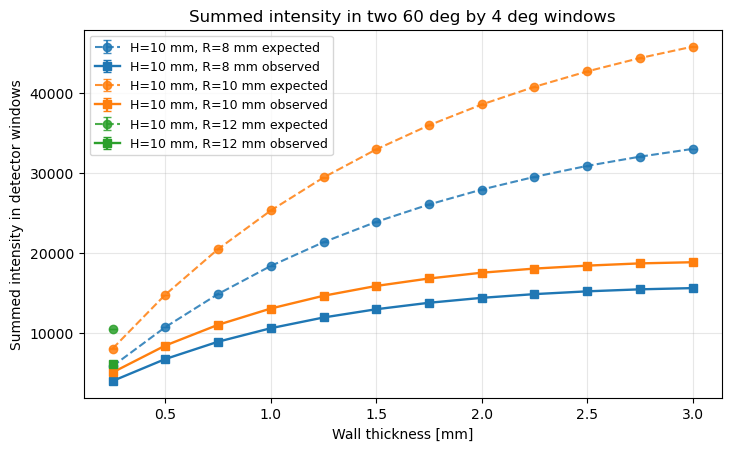

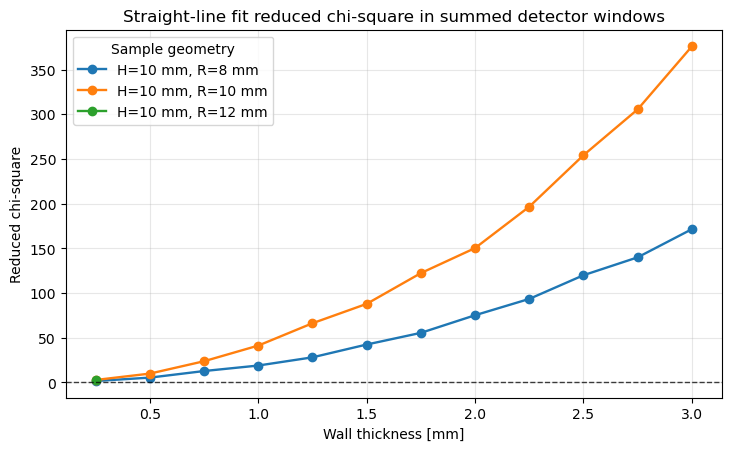

Saved:
/Users/christian/Documents/Study/bachelor_project/geometry_optimization/PSI_instrument/plots/wall_thickness_window_observed_over_expected.png
/Users/christian/Documents/Study/bachelor_project/geometry_optimization/PSI_instrument/plots/wall_thickness_window_absolute_intensity.png
/Users/christian/Documents/Study/bachelor_project/geometry_optimization/PSI_instrument/plots/wall_thickness_window_linear_fit_chi_square.png


In [33]:

fig, ax = plt.subplots(figsize=(7.2, 4.4), constrained_layout=True)
for geometry_label, group in results.groupby('geometry_label', sort=False):
    group = group.sort_values('thickness_mm')
    ax.errorbar(
        group['thickness_mm'],
        group['observed_over_expected'],
        yerr=group['observed_over_expected_err'],
        fmt='o-',
        linewidth=1.7,
        capsize=3,
        label=geometry_label,
    )
ax.axhline(1.0, color='black', linestyle='--', linewidth=1.0, alpha=0.75)
ax.set_xlabel('Wall thickness [mm]')
ax.set_ylabel('Observed / expected intensity')
ax.set_title('Observed / Born expected intensity in summed detector windows')
ax.grid(True, alpha=0.3)
ax.legend(title='Sample geometry')
fig.savefig(plots_dir / 'wall_thickness_window_observed_over_expected.png', dpi=200)
plt.show()

fig, ax = plt.subplots(figsize=(7.2, 4.4), constrained_layout=True)
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
for color, (geometry_label, group) in zip(colors, results.groupby('geometry_label', sort=False)):
    group = group.sort_values('thickness_mm')
    ax.errorbar(
        group['thickness_mm'],
        group['expected_window_sum'],
        yerr=group['expected_window_sum_err'],
        fmt='o--',
        color=color,
        linewidth=1.5,
        capsize=3,
        alpha=0.85,
        label=f'{geometry_label} expected',
    )
    ax.errorbar(
        group['thickness_mm'],
        group['observed_window_sum'],
        yerr=group['observed_window_sum_err'],
        fmt='s-',
        color=color,
        linewidth=1.7,
        capsize=3,
        label=f'{geometry_label} observed',
    )
ax.set_xlabel('Wall thickness [mm]')
ax.set_ylabel('Summed intensity in detector windows')
ax.set_title(f'Summed intensity in two {window_width_deg:g} deg by {2 * latitude_halfwidth_deg:g} deg windows')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)
fig.savefig(plots_dir / 'wall_thickness_window_absolute_intensity.png', dpi=200)
plt.show()

fig, ax = plt.subplots(figsize=(7.2, 4.4), constrained_layout=True)
for geometry_label, group in results.groupby('geometry_label', sort=False):
    group = group.sort_values('thickness_mm')
    ax.plot(
        group['thickness_mm'],
        group['window_linear_fit_reduced_chi_square'],
        'o-',
        linewidth=1.7,
        label=geometry_label,
    )
ax.axhline(1.0, color='black', linestyle='--', linewidth=1.0, alpha=0.75)
ax.set_xlabel('Wall thickness [mm]')
ax.set_ylabel('Reduced chi-square')
ax.set_title('Straight-line fit reduced chi-square in summed detector windows')
ax.grid(True, alpha=0.3)
ax.legend(title='Sample geometry')
fig.savefig(plots_dir / 'wall_thickness_window_linear_fit_chi_square.png', dpi=200)
plt.show()

print('Saved:')
print(plots_dir / 'wall_thickness_window_observed_over_expected.png')
print(plots_dir / 'wall_thickness_window_absolute_intensity.png')
print(plots_dir / 'wall_thickness_window_linear_fit_chi_square.png')
